In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score, adjusted_rand_score
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print("All libraries loaded.")

All libraries loaded.


In [17]:
df = pd.read_csv('music_data.csv')
print(f"Original shape: {df.shape}")
df.head()

Original shape: (57976, 10)


,track_id,acousticness,energy,danceability,loudness,instrumentalness,valence,tempo,genre_label,acoustic_electronic_ratio
0,TR036050,0.094065,0.704616,0.781179,-10.718013,0.265100,0.718007,109.368471,hiphop,0.131630
1,TR022817,0.185549,0.800936,0.629329,-10.384470,0.017074,0.343624,141.483232,hiphop,0.228808
2,TR035890,0.600980,0.939376,0.423810,-4.003605,0.055034,0.756178,157.557540,rock,0.633026
3,TR043899,0.582328,0.881349,0.256391,-5.838230,0.006501,0.647134,75.782406,hiphop,0.653311
4,TR005739,0.074684,0.272076,0.562446,-17.679794,0.367969,0.465180,104.547492,classical,0.264765


In [18]:
# Select numeric features (exclude track_id and any non-numeric)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric columns: {numeric_cols}")

# Features to use (all numeric except we handle ratio separately)
feature_cols = [c for c in numeric_cols if c != 'acoustic_electronic_ratio']
df_features = df[feature_cols].copy()

# Fill missing values (if any)
df_features = df_features.fillna(df_features.median())

# Create log-transformed ratio to fix extreme outliers
ratio_raw = df['acoustic_electronic_ratio'].clip(lower=1e-6, upper=100)
df_features['acoustic_electronic_ratio_log'] = np.log1p(ratio_raw)

print("Log-transformed ratio added. New feature set:")
print(df_features.columns.tolist())

Numeric columns: ['acousticness', 'energy', 'danceability', 'loudness', 'instrumentalness', 'valence', 'tempo', 'acoustic_electronic_ratio']
Log-transformed ratio added. New feature set:
['acousticness', 'energy', 'danceability', 'loudness', 'instrumentalness', 'valence', 'tempo', 'acoustic_electronic_ratio_log']


In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features)
print(f"Standardized data shape: {X_scaled.shape}")

Standardized data shape: (57976, 8)


In [20]:
# Find exact duplicate rows in standardized data
unique_mask = ~pd.DataFrame(X_scaled).duplicated(keep='first')
X_unique = X_scaled[unique_mask]
print(f"Total rows: {X_scaled.shape[0]}, Unique rows (exact duplicates removed): {X_unique.shape[0]}")

# Quick k=2 to see centroid shift
km_full = KMeans(n_clusters=2, random_state=42, n_init=10)
km_uniq = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_full = km_full.fit_predict(X_scaled)
labels_uniq = km_uniq.fit_predict(X_unique)

print("Cluster sizes (full):", np.bincount(labels_full))
print("Cluster sizes (unique):", np.bincount(labels_uniq))

# Use unique data for rest of analysis (avoids centroid bias)
X_analysis = X_unique
print("\nUsing deduplicated data for all further analysis.")

Total rows: 57976, Unique rows (exact duplicates removed): 50000
Cluster sizes (full): [36940 21036]
Cluster sizes (unique): [17952 32048]

Using deduplicated data for all further analysis.


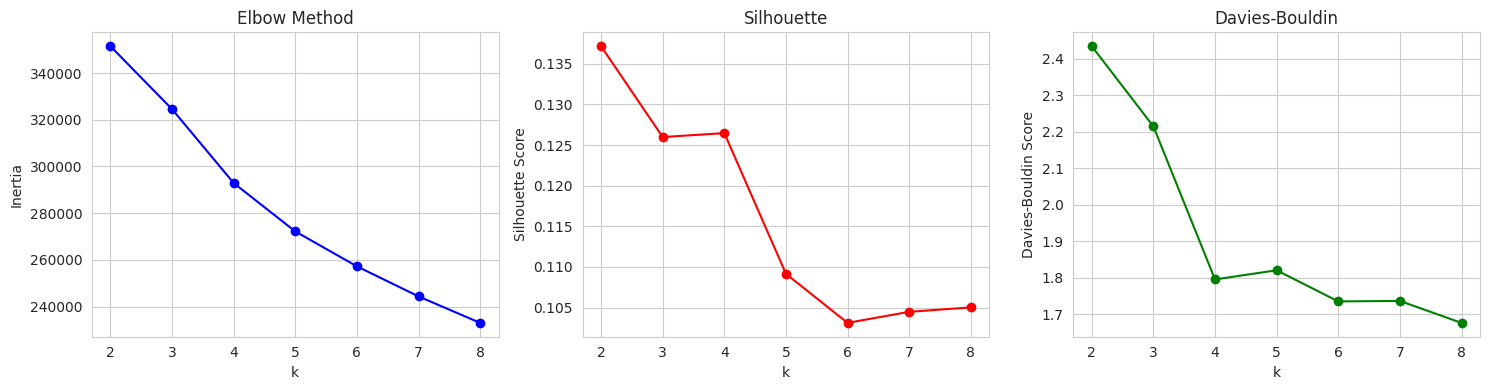

k=2: Silhouette=0.137, DB=2.434
k=3: Silhouette=0.126, DB=2.215
k=4: Silhouette=0.126, DB=1.795
k=5: Silhouette=0.109, DB=1.820
k=6: Silhouette=0.103, DB=1.735
k=7: Silhouette=0.104, DB=1.736
k=8: Silhouette=0.105, DB=1.676


In [21]:
K_range = range(2, 9)
sil_scores = []
db_scores = []
inertias = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_analysis)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_analysis, labels))
    db_scores.append(davies_bouldin_score(X_analysis, labels))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[1].plot(K_range, sil_scores, 'ro-')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette')
axes[2].plot(K_range, db_scores, 'go-')
axes[2].set_xlabel('k')
axes[2].set_ylabel('Davies-Bouldin Score')
axes[2].set_title('Davies-Bouldin')
plt.tight_layout()
plt.show()

for k, sil, db in zip(K_range, sil_scores, db_scores):
    print(f"k={k}: Silhouette={sil:.3f}, DB={db:.3f}")

Final k-means with k=4
Cluster sizes: [24715  8716 16364   205]


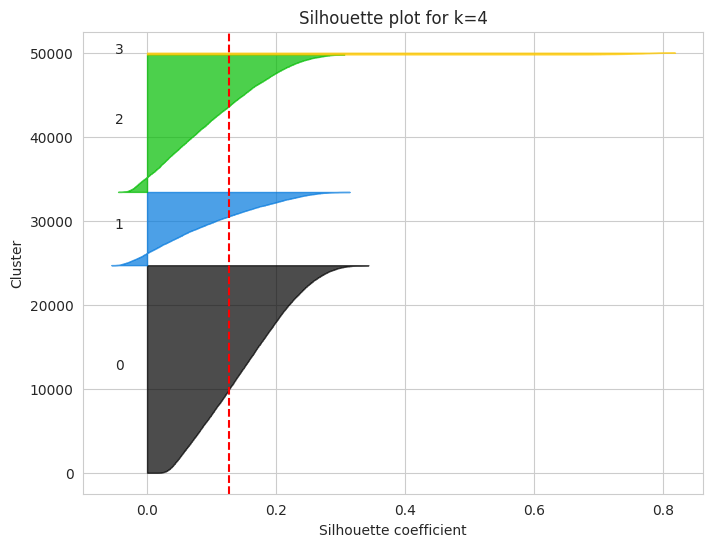

In [22]:
best_k = 4   # as per feedback, go beyond k=2
final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(X_analysis)
print(f"Final k-means with k={best_k}")
print("Cluster sizes:", np.bincount(cluster_labels))

# Silhouette plot
sil_vals = silhouette_samples(X_analysis, cluster_labels)
y_lower = 10
fig, ax = plt.subplots(figsize=(8, 6))
for i in range(best_k):
    ith_sil = sil_vals[cluster_labels == i]
    ith_sil.sort()
    size = len(ith_sil)
    y_upper = y_lower + size
    color = plt.cm.nipy_spectral(float(i) / best_k)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_sil, facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size, str(i))
    y_lower = y_upper + 10
ax.set_xlabel("Silhouette coefficient")
ax.set_ylabel("Cluster")
ax.set_title(f"Silhouette plot for k={best_k}")
ax.axvline(x=silhouette_score(X_analysis, cluster_labels), color='red', linestyle='--')
plt.show()

PC1 explains 23.63%, PC2 explains 12.61%
Total variance captured: 36.24%


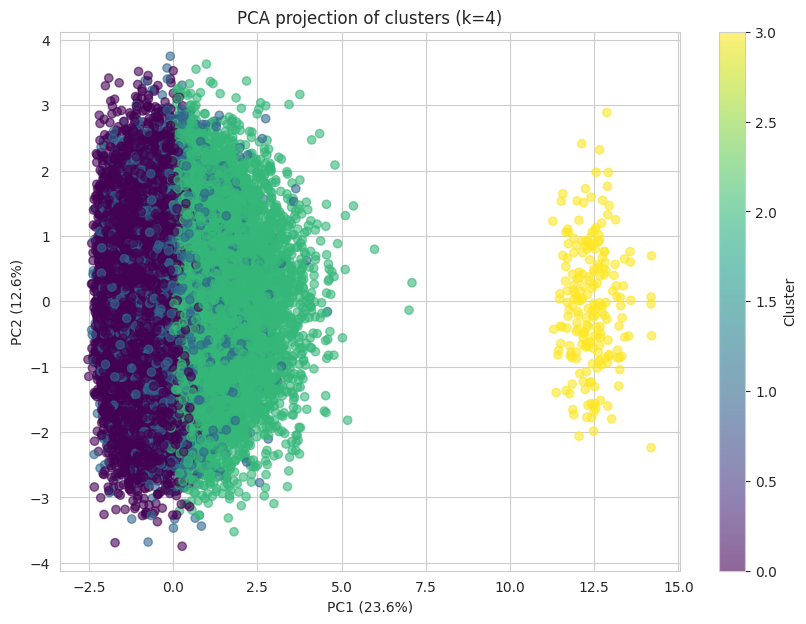

In [23]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_analysis)
expl_var = pca.explained_variance_ratio_
print(f"PC1 explains {expl_var[0]:.2%}, PC2 explains {expl_var[1]:.2%}")
print(f"Total variance captured: {expl_var.sum():.2%}")

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({expl_var[0]:.1%})')
plt.ylabel(f'PC2 ({expl_var[1]:.1%})')
plt.title(f'PCA projection of clusters (k={best_k})')
plt.show()

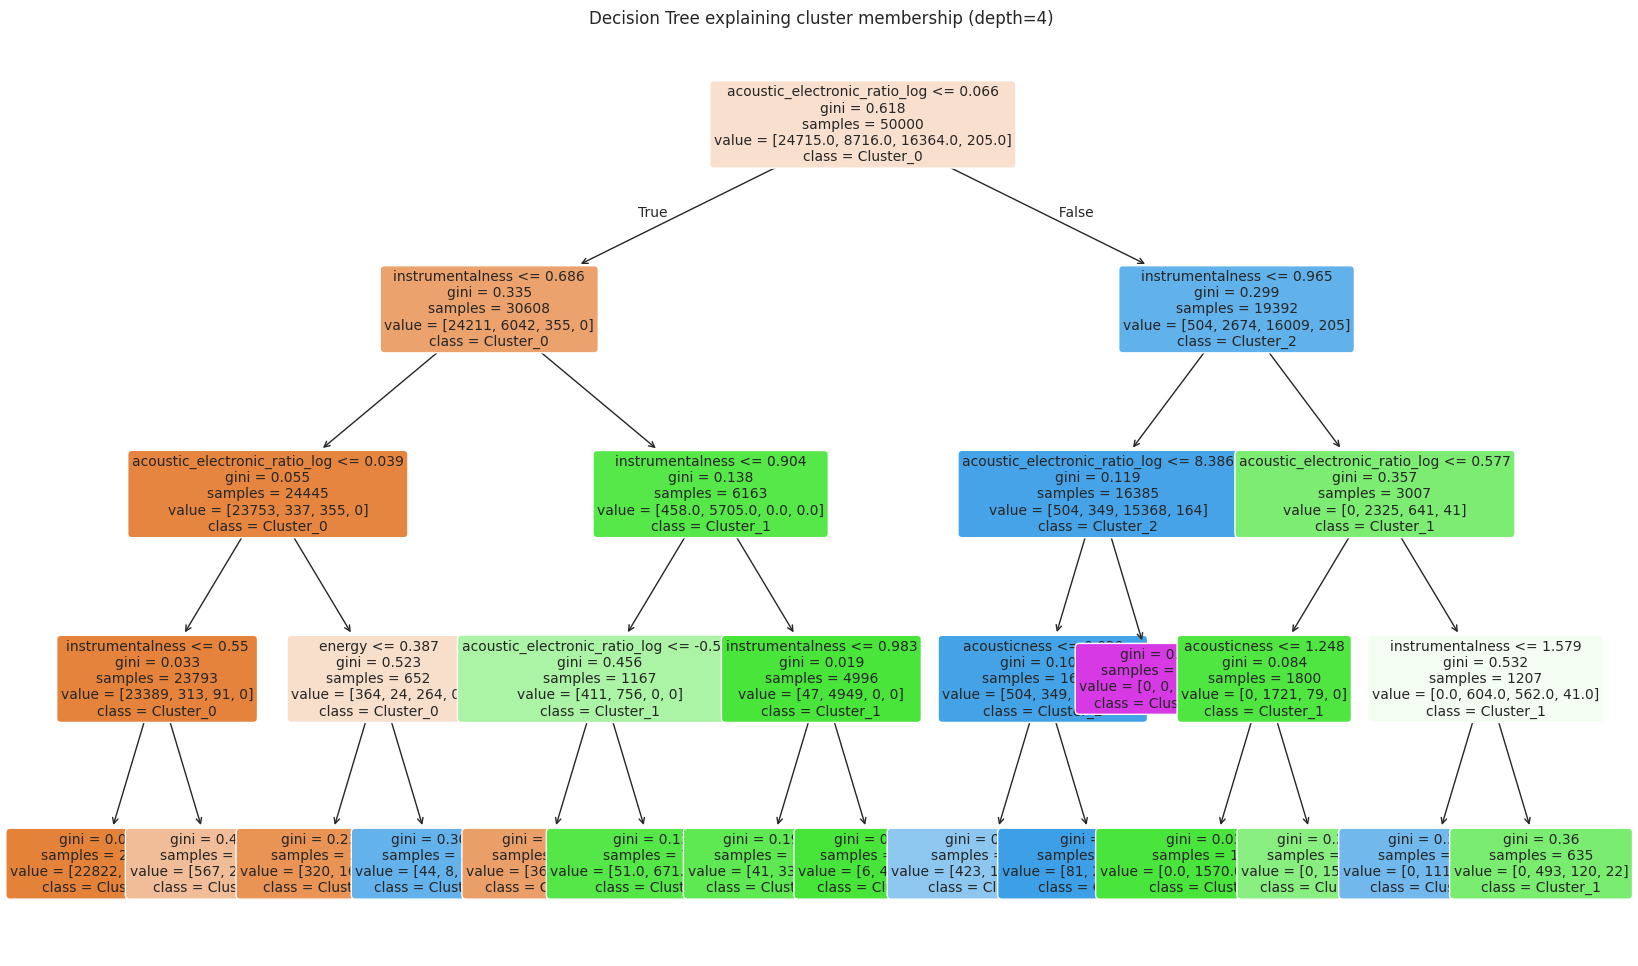

Top 5 most important features for distinguishing clusters:
acoustic_electronic_ratio_log    0.573738
instrumentalness                 0.410932
acousticness                     0.009260
energy                           0.006070
loudness                         0.000000
dtype: float64


In [24]:
# Use original feature names (from df_features) but on standardized X_analysis
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_analysis, cluster_labels)

plt.figure(figsize=(20, 12))
plot_tree(dt, feature_names=df_features.columns.tolist(),
          class_names=[f'Cluster_{i}' for i in range(best_k)],
          filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree explaining cluster membership (depth=4)")
plt.show()

importances = pd.Series(dt.feature_importances_, index=df_features.columns).sort_values(ascending=False)
print("Top 5 most important features for distinguishing clusters:")
print(importances.head(5))

Found 2500 anomalies (5.0%)


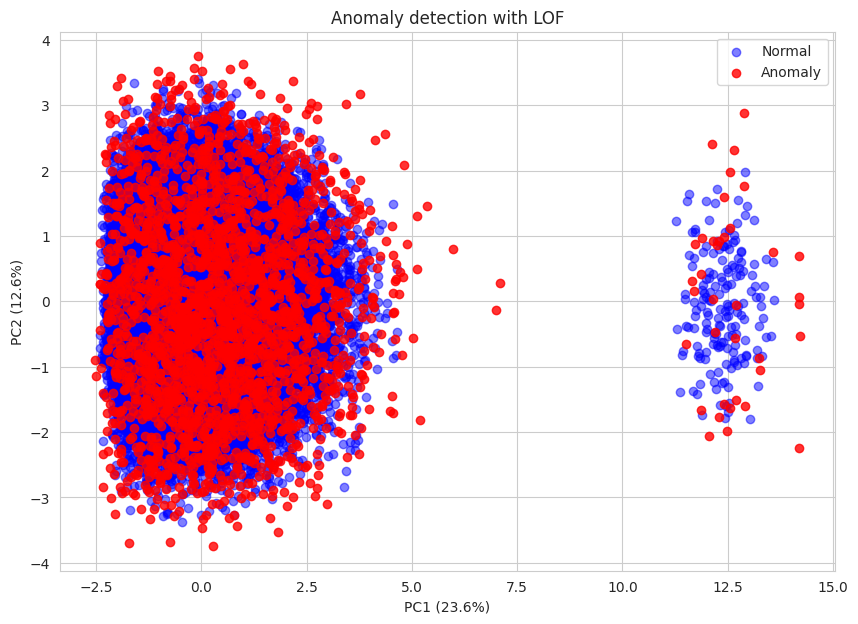

Cluster 0: 717/24715 anomalies (2.9%)
Cluster 1: 810/8716 anomalies (9.3%)
Cluster 2: 936/16364 anomalies (5.7%)
Cluster 3: 37/205 anomalies (18.0%)


In [25]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
outlier_pred = lof.fit_predict(X_analysis)
outlier_mask = (outlier_pred == -1)
print(f"Found {outlier_mask.sum()} anomalies ({outlier_mask.mean():.1%})")

# Visualize anomalies in PCA space
plt.figure(figsize=(10, 7))
plt.scatter(X_pca[~outlier_mask, 0], X_pca[~outlier_mask, 1], c='blue', alpha=0.5, label='Normal')
plt.scatter(X_pca[outlier_mask, 0], X_pca[outlier_mask, 1], c='red', alpha=0.8, label='Anomaly')
plt.xlabel(f'PC1 ({expl_var[0]:.1%})')
plt.ylabel(f'PC2 ({expl_var[1]:.1%})')
plt.title('Anomaly detection with LOF')
plt.legend()
plt.show()

# Which clusters contain most anomalies?
anom_cluster_counts = pd.Series(cluster_labels[outlier_mask]).value_counts().sort_index()
for c in range(best_k):
    total = (cluster_labels == c).sum()
    anom = anom_cluster_counts.get(c, 0)
    print(f"Cluster {c}: {anom}/{total} anomalies ({anom/total:.1%})")

In [26]:
dbscan = DBSCAN(eps=0.5, min_samples=10)
db_labels = dbscan.fit_predict(X_analysis)
n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = list(db_labels).count(-1)
print(f"DBSCAN found {n_clusters_db} clusters and {n_noise} noise points.")

ari = adjusted_rand_score(cluster_labels, db_labels)
print(f"Adjusted Rand Index between k-means (k={best_k}) and DBSCAN: {ari:.3f}")

DBSCAN found 0 clusters and 50000 noise points.
Adjusted Rand Index between k-means (k=4) and DBSCAN: 0.000


In [27]:
# Inverse transform centroids to original scale for interpretation
centers_original = scaler.inverse_transform(final_kmeans.cluster_centers_)
cluster_summary = pd.DataFrame(centers_original, columns=df_features.columns)
cluster_summary.index = [f'Cluster_{i}' for i in range(best_k)]
print("Cluster profiles (original scale averages):")
print(cluster_summary.round(3))

# Give descriptive names
for i in range(best_k):
    row = cluster_summary.iloc[i]
    if row['acousticness'] > 0.6 and row['energy'] < 0.4:
        desc = "Acoustic & calm"
    elif row['energy'] > 0.7 and row['danceability'] > 0.6:
        desc = "Energetic & danceable"
    elif row['acoustic_electronic_ratio_log'] > 2.0:
        desc = "Extreme acoustic bias"
    else:
        desc = "Balanced / mainstream"
    print(f"Cluster {i}: {desc} (size {np.sum(cluster_labels==i)})")

Cluster profiles (original scale averages):
           acousticness  energy  danceability  loudness  instrumentalness  \
Cluster_0         0.186   0.749         0.502   -10.045             0.057   
Cluster_1         0.257   0.718         0.498   -10.122             0.232   
Cluster_2         0.448   0.661         0.496   -10.041             0.067   
Cluster_3         0.899   0.010         0.491    -9.893             0.099   

           valence    tempo  acoustic_electronic_ratio_log  
Cluster_0    0.502  120.022                          0.218  
Cluster_1    0.500  120.070                          0.302  
Cluster_2    0.497  119.121                          0.524  
Cluster_3    0.491  121.596                          3.843  
Cluster 0: Balanced / mainstream (size 24715)
Cluster 1: Balanced / mainstream (size 8716)
Cluster 2: Balanced / mainstream (size 16364)
Cluster 3: Acoustic & calm (size 205)


In [28]:
# Optional: save cluster assignments and anomaly flags to CSV
results_df = pd.DataFrame({
    'cluster': cluster_labels,
    'is_anomaly': outlier_mask
})
results_df.to_csv('cluster_assignments.csv', index=False)
print("Saved cluster assignments to cluster_assignments.csv")

Saved cluster assignments to cluster_assignments.csv
